Imports

In [1]:
import numpy as np
import cvxpy as cp
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict


LMI utilities

In [2]:


def hermitian_part(X):
    return 0.5 * (X + X.conj().T)

def skew_hermitian_part(X):
    return (X - X.conj().T) / (2j)

def is_alignable(M_list, alpha, solver='SCS', verbose=False):
    """Check simultaneous alpha-alignment feasibility for matrices M_i."""
    m, n = M_list[0].shape
    K = cp.Variable((n, n), complex=True)
    tan_alpha = np.tan(alpha)
    constraints = []

    for M in M_list:
        MK = M @ K
        Re = hermitian_part(MK)
        Im = skew_hermitian_part(MK)
        
        # Re(MK) >= M M*
        constraints.append(Re - (M @ M.conj().T) >> 0)
        
        # |Im(MK)| <= tan(alpha) * Re(MK)
        constraints.append(Im - tan_alpha * Re << 0)
        constraints.append(-Im - tan_alpha * Re << 0)

    obj = cp.Minimize(cp.norm(K, "fro"))
    prob = cp.Problem(obj, constraints)
    
    try:
        prob.solve(solver=solver, verbose=verbose)
    except cp.SolverError:
        return False, None
    
    if prob.status in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
        return True, K.value
    return False, None


In [51]:
def system_to_M(A, B, C, omega0=1.0):
    n = A.shape[0]
    jwI_minus_A = 1j * omega0 * np.eye(n) - A
    return C @ np.linalg.inv(jwI_minus_A) @ B


converges for continuous system (which do-mpc will use later)

In [84]:
import numpy as np

def generate_large_dataset(N=50, m=2):
    """
    Generate N real-valued *continuous-time stable* system matrices A.
    Each A is Hurwitz: Re(lambda(A)) < 0, so trajectories x(t)->0.

    Matrices are clustered around rotation phases, like before,
    but properly modified for continuous-time stability.
    """

    # phase centers for rotation (in degrees)
    phase_centers = np.deg2rad(np.array([0, 25, -25, 50, -50, 75]))

    A_list = []

    for i in range(N):
        theta = np.random.choice(phase_centers)

        # Base rotation-like matrix in continuous time
        # This is skew-symmetric: eigenvalues are ±j*theta
        R = np.array([
            [0,        -1],
            [1,         0]
        ])

        # Phase-angle scaling to differentiate clusters
        R = np.cos(theta) * R

        # Symmetric perturbation
        S0 = np.random.randn(m, m)
        S = 0.5 * (S0 + S0.T)    # symmetric

        # Skew-symmetric perturbation
        K0 = np.random.randn(m, m)
        K = 0.5 * (K0 - K0.T)    # skew-symmetric

        # Normalize
        S /= max(np.linalg.norm(S, 2), 1e-6)
        K /= max(np.linalg.norm(K, 2), 1e-6)

        # Stability-enforcing negative diagonal term
        alpha = np.random.uniform(0.3, 1.0)   # strong negative real part

        # Perturbation scales
        beta  = np.random.uniform(0.05, 0.25)   # rotation-like term
        eps_s = np.random.uniform(0.01, 0.08)   # symmetric perturb
        eps_k = np.random.uniform(0.01, 0.08)   # skew-symmetric perturb

        # Final stable matrix
        A = -alpha*np.eye(m) + beta*R + eps_s*S + eps_k*K

        A_list.append(A)

    return A_list


In [85]:
def build_clusters(M_list, alpha_within, solver='SCS', verbose=False):
    clusters = []
    CDs = []

    # First item opens the first cluster
    clusters.append([0])
    CDs.append(0)

    for idx in range(1, len(M_list)):
        M = M_list[idx]
        assigned = False

        # Try each existing cluster
        for c_idx, cluster in enumerate(clusters):
            candidate_M = [M_list[i] for i in (cluster + [idx])]
            feasible, _ = is_alignable(candidate_M, alpha_within, solver=solver)
            if feasible:
                clusters[c_idx].append(idx)
                assigned = True
                break
        
        if not assigned:
            # Create new consensus-dynamic cluster
            clusters.append([idx])
            CDs.append(idx)

    return clusters, CDs


In [86]:
if __name__ == "__main__":
    np.random.seed(1)

    # Generate 50 random dynamics
    M_list = generate_large_dataset(N=50, m=2)

    # Require each cluster to have diversity <= 5 degrees
    alpha_within = np.deg2rad(5)

    clusters, CDs = build_clusters(M_list, alpha_within)

    print("\n=== RESULTS ===")
    print(f"Number of clusters (consensus dynamics): {len(clusters)}\n")

    for i, cl in enumerate(clusters):
        print(f"Cluster {i}: size {len(cl)}  |  members = {cl[:10]}{' ...' if len(cl)>10 else ''}")


/Users/apple/opt/anaconda3/envs/safe/lib/python3.10/site-packages/cvxpy/problems/problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(



=== RESULTS ===
Number of clusters (consensus dynamics): 6

Cluster 0: size 24  |  members = [0, 1, 2, 3, 4, 6, 11, 17, 21, 23] ...
Cluster 1: size 4  |  members = [5, 16, 20, 31]
Cluster 2: size 13  |  members = [7, 9, 12, 13, 15, 19, 22, 25, 29, 36] ...
Cluster 3: size 2  |  members = [8, 28]
Cluster 4: size 6  |  members = [10, 14, 18, 24, 41, 47]
Cluster 5: size 1  |  members = [30]


Hierarchical DB node classes

In [75]:
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict
import numpy as np

# ---- Node types (same as before, unchanged) --------------------------------

@dataclass
class ObsInstance:
    grid_pos: Tuple[int, int]      # (row, col): 0,0 = upper-left
    timestamp: float = 0.0
    traj_ref: int = None           # can later hold trajectory index/id

@dataclass
class ObsType:
    name: str
    dyn_id: int
    instances: List[ObsInstance] = field(default_factory=list)

@dataclass
class Dyn:
    dyn_id: int
    cluster_id: int
    M: np.ndarray
    obs_types: Dict[str, ObsType] = field(default_factory=dict)

@dataclass
class ConsensusDyn:
    cluster_id: int
    cd_dyn_idx: int
    M_cd: np.ndarray
    dyn_children: Dict[int, Dyn] = field(default_factory=dict)

@dataclass
class HierarchicalDB:
    consensus_nodes: Dict[int, ConsensusDyn] = field(default_factory=dict)
    dyn_to_cluster: Dict[int, int] = field(default_factory=dict)
    dyn_nodes: Dict[int, Dyn] = field(default_factory=dict)


generate evenly spaced obstacle positions

In [38]:
import numpy as np
import random

def generate_uniform_obstacle_centers(
    grid_height=20,
    grid_width=20,
    grids_per_quadrant=3,
):
    """
    Generate evenly spaced obstacle centers in a square plane centered at origin.

    We use a continuous coordinate system:

      x1 in [-2*grid_height, 2*grid_height]
      x2 in [-2*grid_height, 2*grid_height]

    The axes x1=0, x2=0 split the plane into 4 quadrants.
    Each quadrant is divided into (grids_per_quadrant x grids_per_quadrant)
    cells, and we place one center at the center of each cell.

    Total centers = 4 * grids_per_quadrant^2.
    """

    centers = []

    # positive side extents ####
    half_h = 2*grid_height
    half_w = 2*grid_width

    # spacing of cell centers in one positive half-plane
    # e.g. for grids_per_quadrant=3, we get 3 centers on (0, half_h]:
    # (1/6)*half_h, (3/6)*half_h, (5/6)*half_h
    x_pos = (np.arange(grids_per_quadrant) + 0.5) * (half_h / grids_per_quadrant)
    y_pos = (np.arange(grids_per_quadrant) + 0.5) * (half_w / grids_per_quadrant)

    # quadrants: (sign_x, sign_y)
    quadrants = [
        (1, 1),
        (-1, 1),
        (-1, -1),
        (1, -1),
    ]

    for sx, sy in quadrants:
        for cx in x_pos:
            for cy in y_pos:
                x_center = sx * cx
                y_center = sy * cy
                centers.append((x_center, y_center))

    return centers


build the DB

In [76]:
def build_hierarchical_db_single_obstacle(
    M_list,
    clusters,
    CDs,
    obstacle_type_names=None,
    grid_height=5,
    grid_width=5,
    grids_per_quadrant=3,      # <-- controls "9" (per quadrant grid size)
    num_positions_per_type=None,
    seed=0
) -> HierarchicalDB:
    """
    Build S1 hierarchy for the single-obstacle case with UNIFORMLY-SPACED positions.

    Plane is centered at origin:
        x1 in [-grid_height, grid_height]
        x2 in [-grid_width,  grid_width]

    We divide it by x1=0 and x2=0 into 4 quadrants, and each quadrant is
    further divided into (grids_per_quadrant x grids_per_quadrant) cells.

    For each Dyn and each obstacle type, we place at most
        N_centers = 4 * grids_per_quadrant^2
    obstacle instances at the centers of these cells.

    If num_positions_per_type is given, we use up to
        min(num_positions_per_type, N_centers) positions per type.
    """
    if obstacle_type_names is None:
        obstacle_type_names = ["car", "wall", "static_cone", "pedestrian", "truck"]

    random.seed(seed)
    db = HierarchicalDB()

    # ---- Build CD nodes ----
    for cluster_id, cluster in enumerate(clusters):
        cd_dyn_idx = CDs[cluster_id]
        cd_node = ConsensusDyn(
            cluster_id=cluster_id,
            cd_dyn_idx=cd_dyn_idx,
            M_cd=M_list[cd_dyn_idx]
        )
        db.consensus_nodes[cluster_id] = cd_node

    # ---- Precompute evenly spaced obstacle centers ----
    uniform_centers = generate_uniform_obstacle_centers(
        grid_height=grid_height,
        grid_width=grid_width,
        grids_per_quadrant=grids_per_quadrant
    )
    total_centers = len(uniform_centers)  # = 4 * grids_per_quadrant^2

    if num_positions_per_type is None:
        num_positions_per_type = total_centers
    num_positions_per_type = min(num_positions_per_type, total_centers)

    print(f"Total uniform centers available: {total_centers}")
    print(f"Using {num_positions_per_type} centers per obstacle type.\n")

    # ---- Build Dyn + obstacle type children ----
    for cluster_id, cluster in enumerate(clusters):
        cd_node = db.consensus_nodes[cluster_id]

        for dyn_id in cluster:
            dyn_node = Dyn(
                dyn_id=dyn_id,
                cluster_id=cluster_id,
                M=M_list[dyn_id]
            )

            for name in obstacle_type_names:
                obs_type = ObsType(name=name, dyn_id=dyn_id)

                # Use first num_positions_per_type centers (or shuffle, if you want)
                # random.shuffle(uniform_centers)  # uncomment if you want per-dyn permutation
                selected_centers = uniform_centers[:num_positions_per_type]

                for (cx, cy) in selected_centers:
                    # IMPORTANT: we now store the CENTER directly as grid_pos
                    # (cx, cy) lives in continuous coordinates, centered at origin.
                    obs_type.instances.append(
                        ObsInstance(grid_pos=(cx, cy))
                    )

                dyn_node.obs_types[name] = obs_type

            cd_node.dyn_children[dyn_id] = dyn_node
            db.dyn_to_cluster[dyn_id] = cluster_id
            db.dyn_nodes[dyn_id] = dyn_node

    return db


DB with parameters specified

In [87]:
db = build_hierarchical_db_single_obstacle(
    M_list,
    clusters,
    CDs,
    grid_height=5,
    grid_width=5,
    grids_per_quadrant=3,   # 3x3 → 9 per quadrant
    num_positions_per_type=36,  # (optional; 36 is the max)
    seed=42
)


Total uniform centers available: 36
Using 36 centers per obstacle type.



build the obstacles based on the center position and type specified

In [57]:
OBST_RADIUS_FACTORS = {
    "car":         1.0,
    "wall":        1.5,
    "static_cone": 0.5,
    "pedestrian":  0.8,
    "truck":       1.8,
}

def build_single_obstacle_from_db(
    db,
    dyn_id,
    obs_type_name="car",
    instance_idx=0,
    base_cell_radius=0.5
):
    """
    Build a SINGLE circular obstacle for a given dyn_id, obstacle type and instance index.

    Now we interpret ObsInstance.grid_pos as the OBSTACLE CENTER directly (cx, cy).
    """
    dyn_node = db.dyn_nodes[dyn_id]
    if obs_type_name not in dyn_node.obs_types:
        raise ValueError(f"Obstacle type '{obs_type_name}' not found for dyn_id {dyn_id}")

    obs_type = dyn_node.obs_types[obs_type_name]

    if instance_idx < 0 or instance_idx >= len(obs_type.instances):
        raise IndexError(f"instance_idx {instance_idx} out of range for type '{obs_type_name}'")

    inst = obs_type.instances[instance_idx]
    cx, cy = inst.grid_pos   # already center coordinates

    factor = OBST_RADIUS_FACTORS.get(obs_type_name, 1.0)
    radius = base_cell_radius * factor

    obstacle = {
        "center": (cx, cy),
        "radius": radius,
        "type":   obs_type_name
    }
    return [obstacle]


In [88]:
obs = build_single_obstacle_from_db(
    db,
    17,
    obs_type_name="car",
    instance_idx=3,
    base_cell_radius=0.5
)

In [59]:
print(obs)

[{'center': (np.float64(5.0), np.float64(1.6666666666666667)), 'radius': 0.5, 'type': 'car'}]


In [49]:
type(obs)

list

DB structure display

In [60]:
def show_db_structure(db, max_clusters=10, max_dyns_per_cluster=5, max_instances_per_type=5):
    """
    Pretty-print a summary of the hierarchical DB:
        ConsensusDyn -> Dyn -> ObsType -> ObsInstance(grid_pos)
    """

    print("========== DB SUMMARY ==========")
    print(f"Number of consensus dynamics (clusters): {len(db.consensus_nodes)}")
    print(f"Number of dynamics (Dyn nodes):         {len(db.dyn_nodes)}")
    print("================================\n")

    # Iterate over clusters
    for c_idx, (cluster_id, cd_node) in enumerate(sorted(db.consensus_nodes.items())):
        if c_idx >= max_clusters:
            print(f"... ({len(db.consensus_nodes) - max_clusters} more clusters not shown)")
            break

        print(f"[Cluster {cluster_id}]  CD dyn_idx = {cd_node.cd_dyn_idx}")
        dyn_ids = sorted(cd_node.dyn_children.keys())
        print(f"  #Dyn children: {len(dyn_ids)}")

        # Show up to max_dyns_per_cluster dynamics in each cluster
        for j, dyn_id in enumerate(dyn_ids[:max_dyns_per_cluster]):
            dyn_node = cd_node.dyn_children[dyn_id]
            print(f"    Dyn {dyn_id}: obstacle types = {list(dyn_node.obs_types.keys())}")

            # Show some instances for each type
            for obs_type_name, obs_type in dyn_node.obs_types.items():
                print(f"      Type '{obs_type_name}': {len(obs_type.instances)} positions")
                for inst in obs_type.instances[:max_instances_per_type]:
                    print(f"        grid_pos = {inst.grid_pos}")
                if len(obs_type.instances) > max_instances_per_type:
                    print(f"        ... ({len(obs_type.instances) - max_instances_per_type} more)")

        if len(dyn_ids) > max_dyns_per_cluster:
            print(f"    ... ({len(dyn_ids) - max_dyns_per_cluster} more dyns in this cluster)")
        print()


In [43]:
show_db_structure(db, max_clusters=10, max_dyns_per_cluster=5, max_instances_per_type=5)

========== DB SUMMARY ==========
Number of consensus dynamics (clusters): 6
Number of dynamics (Dyn nodes):         50

[Cluster 0]  CD dyn_idx = 0
  #Dyn children: 8
    Dyn 0: obstacle types = ['car', 'wall', 'static_cone', 'pedestrian', 'truck']
      Type 'car': 36 positions
        grid_pos = (np.float64(1.6666666666666667), np.float64(1.6666666666666667))
        grid_pos = (np.float64(1.6666666666666667), np.float64(5.0))
        grid_pos = (np.float64(1.6666666666666667), np.float64(8.333333333333334))
        grid_pos = (np.float64(5.0), np.float64(1.6666666666666667))
        grid_pos = (np.float64(5.0), np.float64(5.0))
        ... (31 more)
      Type 'wall': 36 positions
        grid_pos = (np.float64(1.6666666666666667), np.float64(1.6666666666666667))
        grid_pos = (np.float64(1.6666666666666667), np.float64(5.0))
        grid_pos = (np.float64(1.6666666666666667), np.float64(8.333333333333334))
        grid_pos = (np.float64(5.0), np.float64(1.6666666666666667))
  

In [89]:
import pickle

# Save M_list
with open("M_list.pkl", "wb") as f:
    pickle.dump(M_list, f)

# Save db
with open("db.pkl", "wb") as f:
    pickle.dump(db, f)

print("Saved M_list.pkl and db.pkl!")


Saved M_list.pkl and db.pkl!


MPC runner for a single (dyn, type, instance)

In [90]:
import do_mpc
from casadi import *

def create_mpc(A, obstacles, dt=0.01):
    model = do_mpc.model.Model('continuous')
    B = np.array([[0.0], [1.0]])

    x1 = model.set_variable(var_type='_x', var_name='x1', shape=(1, 1))
    x2 = model.set_variable(var_type='_x', var_name='x2', shape=(1, 1))
    u  = model.set_variable(var_type='_u', var_name='u',  shape=(1, 1))

    model.set_rhs('x1', A[0, 0]*x1 + A[0, 1]*x2 + B[0, 0]*u)
    model.set_rhs('x2', A[1, 0]*x1 + A[1, 1]*x2 + B[1, 0]*u)
    model.setup()

    mpc = do_mpc.controller.MPC(model)
    mpc.set_param(
        n_horizon=6,  ###predictive horizon hard coded here
        t_step=dt,
        state_discretization='collocation',
        collocation_type='radau',
        store_full_solution=True,
    )

    mterm = 10*x1**2 + x2**2
    lterm = 10*x1**2 + x2**2 + u**2
    mpc.set_objective(mterm=mterm, lterm=lterm)
    mpc.set_rterm(u=0.0)

    mpc.bounds['lower', '_x', 'x1'] = -10
    mpc.bounds['upper', '_x', 'x1'] =  10
    mpc.bounds['lower', '_x', 'x2'] = -10
    mpc.bounds['upper', '_x', 'x2'] =  10
    mpc.bounds['lower', '_u', 'u']  = -5
    mpc.bounds['upper', '_u', 'u']  =  5

    # Single (or few) obstacles
    if obstacles is not None:
        for i, obs in enumerate(obstacles):
            cx, cy = obs["center"]
            r = obs["radius"]
            cons = -((x1 - cx)**2 + (x2 - cy)**2) + r**2
            mpc.set_nl_cons(f"obstacle_{i}", cons, ub=0.0)

    mpc.setup()

    simulator = do_mpc.simulator.Simulator(model)
    simulator.set_param(integration_tool='cvodes', t_step=dt)
    simulator.setup()

    return model, mpc, simulator

def simulate_scenario(A, obstacles, dt=0.01, n_steps=500, start_point=(5, 5)):
    # Start from chosen point
    x0 = np.array([[start_point[0]], [start_point[1]]])

    model, mpc, simulator = create_mpc(A, obstacles, dt=dt)
    mpc.x0 = x0
    simulator.x0 = x0
    mpc.set_initial_guess()

    # -------------------------------------------
    # Always start state_hist with the initial x0
    # Convert to 1D shape (2,)
    # -------------------------------------------
    state_hist = []
    state_hist.append(x0.squeeze().copy())

    input_hist = []
    total_cost = 0.0

    for _ in range(n_steps):
        u0 = mpc.make_step(x0)
        x_next = simulator.make_step(u0)

        # Ensure consistent shapes
        x_next = np.array(x_next).reshape(-1, 1)
        u0     = np.array(u0).reshape(-1, 1)

        # Save this step
        state_hist.append(x_next.squeeze().copy())
        input_hist.append(u0.squeeze().copy())

        # Cost
        x1_val, x2_val = x_next[0, 0], x_next[1, 0]
        u_val = u0[0, 0]
        stage_cost = 10*x1_val**2 + x2_val**2 + u_val**2
        total_cost += stage_cost * dt

        # Move to next step
        x0 = x_next

    # Terminal cost
    x1_val, x2_val = x0[0, 0], x0[1, 0]
    total_cost += (10*x1_val**2 + x2_val**2) * dt

    # Convert lists → np arrays of shape (T+1, 2) and (T, 1)
    return np.array(state_hist), np.array(input_hist), total_cost


Testing: Run one scenario and plot

[[-0.30527363  0.01850708]
 [-0.03421617 -0.29803076]]
Selected scenario: dyn_id=5, type=car, inst=14
Obstacle: center=(np.float64(-5.0), np.float64(8.333333333333334)), radius=0.50
This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:      158
Number of nonzeros in inequality constraint Jacobian.:       12
Number of nonzeros in Lagrangian Hessian.............:       20

Total number of variables............................:       62
                     variables with only lower bounds:        0
                variables with lower and upper bounds:       46
                     variables with only upper bounds:        0
Total number of equality constraints.................:       50
Total number of inequality constraints...............:        6
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only 

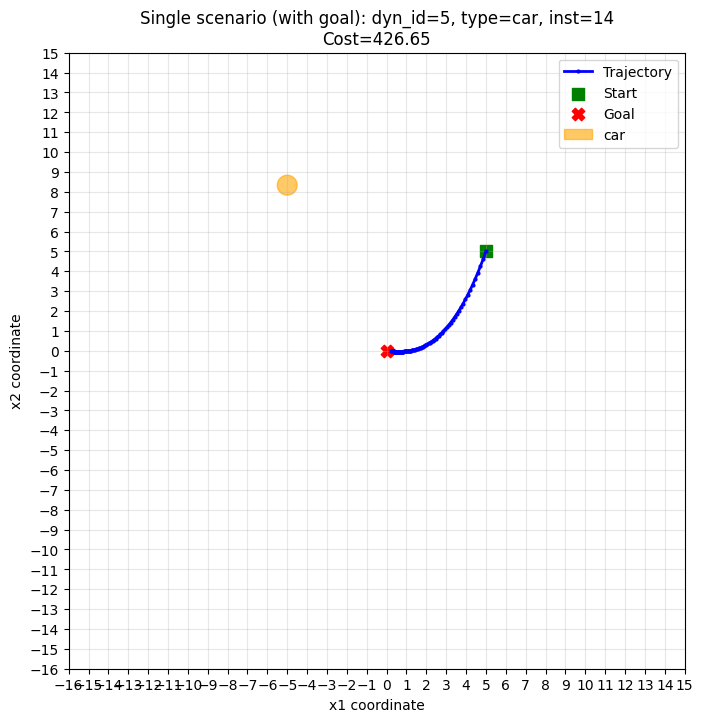

In [93]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# --------- choose one scenario ---------------------------------
dyn_id        = 5           # any dyn_id in db.dyn_nodes
obs_type_name = "car"       # obstacle type
instance_idx  = 14           # one of the 50 positions

dt       = 0.1
n_steps  = 100               # with dt=0.1 and horizon=40, this is 8 seconds
grid_H   = 5
grid_W   = 5
base_cell_radius = 0.5

# Use the real dynamics from your dataset
A = np.array(M_list[dyn_id], dtype=float)
print(A)

# --------- single obstacle from DB -----------------------------
obstacles = build_single_obstacle_from_db(
    db,
    dyn_id,
    obs_type_name=obs_type_name,
    instance_idx=instance_idx,
    base_cell_radius=base_cell_radius
)

print(f"Selected scenario: dyn_id={dyn_id}, type={obs_type_name}, inst={instance_idx}")
print(f"Obstacle: center={obstacles[0]['center']}, radius={obstacles[0]['radius']:.2f}")

# Start = upper-left cell center, goal = lower-right cell center
goal_point = (0, 0)
start_point  = (grid_H, grid_W)

# --------- run MPC with explicit goal --------------------------
states, inputs, cost = simulate_scenario(
    A=A,
    obstacles=obstacles,
    dt=dt,
    n_steps=n_steps,
    start_point = (5, 5)
)


print(f"Total cost: {cost:.3f}")
print(f"States shape: {states.shape}, Inputs shape: {inputs.shape}")

# --------- plot trajectory + obstacle --------------------------
xs = states[:, 0]
ys = states[:, 1]

fig, ax = plt.subplots(figsize=(8, 8))

# Trajectory
ax.plot(xs, ys, "-o", markersize=2, linewidth=2, color="blue", label="Trajectory")

# Start & Goal
ax.scatter(start_point[0], start_point[1], s=80, c="green", marker="s", label="Start")
ax.scatter(goal_point[0],  goal_point[1],  s=80, c="red",   marker="X", label="Goal")

# Obstacle
cx, cy = obstacles[0]["center"]
r      = obstacles[0]["radius"]
circle = patches.Circle((cx, cy), r, color="orange", alpha=0.6, label=obs_type_name)
ax.add_patch(circle)


ax.set_aspect("equal")
ax.set_xlim(-3*grid_H, 3*grid_H) 

ax.set_ylim(-3*grid_W, 3*grid_W)
ax.set_xticks(range(-3*grid_H-1, 3*grid_H+1))
ax.set_yticks(range(-3*grid_H-1, 3*grid_W+1))
ax.grid(alpha=0.3)

ax.set_xlabel("x1 coordinate")
ax.set_ylabel("x2 coordinate")
ax.set_title(
    f"Single scenario (with goal): dyn_id={dyn_id}, type={obs_type_name}, inst={instance_idx}\n"
    f"Cost={cost:.2f}"
)
ax.legend()
plt.show()


later......

Loop over all scenarios and save

In [80]:
import os
import numpy as np

def save_trajectory_npz(dyn_id,
                        cluster_id,
                        obs_type_name,
                        instance_idx,
                        states,
                        inputs,
                        cost,
                        dt,
                        n_horizon,
                        start_point,
                        out_dir="traj_output_single"):
    """
    Save one trajectory to disk as traj_dyn_<dyn_id>_<type>_<instance>.npz.
    """
    os.makedirs(out_dir, exist_ok=True)
    fname = f"traj_dyn_{dyn_id}_{obs_type_name}_{instance_idx}.npz"
    path = os.path.join(out_dir, fname)

    np.savez(
        path,
        dyn_id=dyn_id,
        cluster_id=cluster_id,
        obs_type=obs_type_name,
        instance_idx=instance_idx,
        states=states,
        inputs=inputs,
        cost=cost,
        dt=dt,
        n_horizon=n_horizon,
        start_point=np.array(start_point),
    )
    print(f"  Saved {path}")


def run_all_scenarios_and_save(db,
                               A_list,
                               dt=0.1,
                               n_steps=800,
                               n_horizon=6,
                               base_cell_radius=0.5,
                               max_instances_per_type=20,
                               start_point=(5, 5),
                               out_dir="traj_output_single"):
    """
    Loop over all dyn_id, all obstacle types, and up to max_instances_per_type
    obstacle positions per type, simulate and save trajectories (no plotting).
    """
    for dyn_id, dyn_node in db.dyn_nodes.items():
        cluster_id = db.dyn_to_cluster[dyn_id]
        print(f"\n=== Dyn {dyn_id} (cluster {cluster_id}) ===")

        A = A_list[dyn_id]

        for obs_type_name, obs_type in dyn_node.obs_types.items():
            n_positions = min(len(obs_type.instances), max_instances_per_type)
            print(f"  Obstacle type '{obs_type_name}' with {n_positions} positions")

            for idx in range(n_positions):
                obstacles = build_single_obstacle_from_db(
                    db=db,
                    dyn_id=dyn_id,
                    obs_type_name=obs_type_name,
                    instance_idx=idx,
                    base_cell_radius=base_cell_radius
                )

                states, inputs, cost = simulate_scenario(
                    A=A,
                    obstacles=obstacles,
                    dt=dt,
                    n_steps=n_steps,
                    start_point=start_point
                )

                save_trajectory_npz(
                    dyn_id=dyn_id,
                    cluster_id=cluster_id,
                    obs_type_name=obs_type_name,
                    instance_idx=idx,
                    states=states,
                    inputs=inputs,
                    cost=cost,
                    dt=dt,
                    n_horizon=n_horizon,
                    start_point=start_point,
                    out_dir=out_dir
                )

    print("\nAll scenarios simulated and saved.")


Loop over only car scenarios and save

In [87]:
import os
import numpy as np

def save_trajectory_npz(dyn_id,
                        cluster_id,
                        obs_type_name,
                        instance_idx,
                        states,
                        inputs,
                        cost,
                        dt,
                        n_horizon,
                        start_point,
                        out_dir="traj_output_single"):
    os.makedirs(out_dir, exist_ok=True)
    fname = f"traj_dyn_{dyn_id}_{obs_type_name}_{instance_idx}.npz"
    path = os.path.join(out_dir, fname)

    np.savez(
        path,
        dyn_id=dyn_id,
        cluster_id=cluster_id,
        obs_type=obs_type_name,
        instance_idx=instance_idx,
        states=states,
        inputs=inputs,
        cost=cost,
        dt=dt,
        n_horizon=n_horizon,
        start_point=np.array(start_point),
    )
    print(f"  Saved {path}")


def run_car_scenarios_and_save(db,
                                A_list,
                                dt=0.1,
                                n_steps=800,
                                n_horizon=6,
                                base_cell_radius=0.5,
                                max_instances_per_type=20,
                                start_point=(5, 5),
                                out_dir="traj_output_single"):
    """
    Loop over all dyn_id but **ONLY run scenarios using the 'car' obstacle type**.
    All other obstacle types are ignored.
    """
    TARGET_TYPE = "car"       # <---- ONLY THIS TYPE

    for dyn_id, dyn_node in db.dyn_nodes.items():
        cluster_id = db.dyn_to_cluster[dyn_id]
        print(f"\n=== Dyn {dyn_id} (cluster {cluster_id}) ===")

        A = A_list[dyn_id]

        # ------------------------------------------
        # Only run CAR scenarios
        # ------------------------------------------
        if TARGET_TYPE not in dyn_node.obs_types:
            print(f"  Dyn {dyn_id} has no 'car' obstacle type. Skipping.")
            continue

        obs_type = dyn_node.obs_types[TARGET_TYPE]
        n_positions = min(len(obs_type.instances), max_instances_per_type)
        print(f"  Obstacle type 'car' with {n_positions} positions")

        for idx in range(n_positions):
            obstacles = build_single_obstacle_from_db(
                db=db,
                dyn_id=dyn_id,
                obs_type_name=TARGET_TYPE,
                instance_idx=idx,
                base_cell_radius=base_cell_radius
            )

            states, inputs, cost = simulate_scenario(
                A=A,
                obstacles=obstacles,
                dt=dt,
                n_steps=n_steps,
                start_point=start_point
            )

            save_trajectory_npz(
                dyn_id=dyn_id,
                cluster_id=cluster_id,
                obs_type_name=TARGET_TYPE,
                instance_idx=idx,
                states=states,
                inputs=inputs,
                cost=cost,
                dt=dt,
                n_horizon=n_horizon,
                start_point=start_point,
                out_dir=out_dir
            )

    print("\nAll CAR scenarios simulated and saved.")


In [ ]:

# Example parameters
dt = 0.1
n_steps = 800
start_point = (5, 5)  # upper-left cell center

run_car_scenarios_and_save( ###or "all"
    db=db,
    A_list=M_list,
    dt=dt,
    n_steps=n_steps,
    base_cell_radius=0.5,
    max_instances_per_type=20,
    start_point=start_point,
    out_dir="traj_output_single"
)

Load a saved trajectory for a given scenario and plot it

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def load_and_plot_trajectory(dyn_id,
                             obs_type_name,
                             instance_idx,
                             db,
                             grid_H=5,
                             grid_W=5,
                             base_cell_radius=0.5,
                             traj_dir="traj_output_single"):
    """
    Load a saved trajectory from disk and plot it with the obstacle.
    Does NOT re-run MPC.
    """
    # ---- Load saved trajectory ----
    fname = f"traj_dyn_{dyn_id}_{obs_type_name}_{instance_idx}.npz"
    path = os.path.join(traj_dir, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Trajectory file not found: {path}")

    data = np.load(path)
    states     = data["states"]
    inputs     = data["inputs"]
    cost       = float(data["cost"])
    dt         = float(data["dt"])
    n_horizon  = int(data["n_horizon"])
    start_point = tuple(data["start_point"])

    xs = states[:, 0]
    ys = states[:, 1]

    # ---- Rebuild obstacle from DB (for plotting) ----
    obstacles = build_single_obstacle_from_db(
        db=db,
        dyn_id=dyn_id,
        obs_type_name=obs_type_name,
        instance_idx=instance_idx,
        base_cell_radius=base_cell_radius
    )
    cx, cy = obstacles[0]["center"]
    r      = obstacles[0]["radius"]


    # --------- plot trajectory + obstacle --------------------------
    xs = states[:, 0]
    ys = states[:, 1]

    fig, ax = plt.subplots(figsize=(8, 8))

    # Trajectory
    ax.plot(xs, ys, "-o", markersize=2, linewidth=2, color="blue", label="Trajectory")

    # Start & Goal
    ax.scatter(start_point[0], start_point[1], s=80, c="green", marker="s", label="Start")
    ax.scatter(goal_point[0],  goal_point[1],  s=80, c="red",   marker="X", label="Goal")

    # Obstacle
    cx, cy = obstacles[0]["center"]
    r      = obstacles[0]["radius"]
    circle = patches.Circle((cx, cy), r, color="orange", alpha=0.6, label=obs_type_name)
    ax.add_patch(circle)

    # Grid & limits
    ax.set_aspect("equal")
    ax.set_xlim(-3*grid_H, 3*grid_H)
    ax.set_ylim(-3*grid_W, 3*grid_W)
    ax.set_xticks(range(-3*grid_H-1, 3*grid_H+1)) ###
    ax.set_yticks(range(-3*grid_H-1, 3*grid_W+1))
    ax.grid(alpha=0.3)

    ax.set_xlabel("x1 coordinate")
    ax.set_ylabel("x2 coordinate")
    ax.set_title(
        f"Single scenario (with goal): dyn_id={dyn_id}, type={obs_type_name}, inst={instance_idx}\n"
        f"Cost={cost:.2f}"
    )
    ax.legend()
    plt.show()


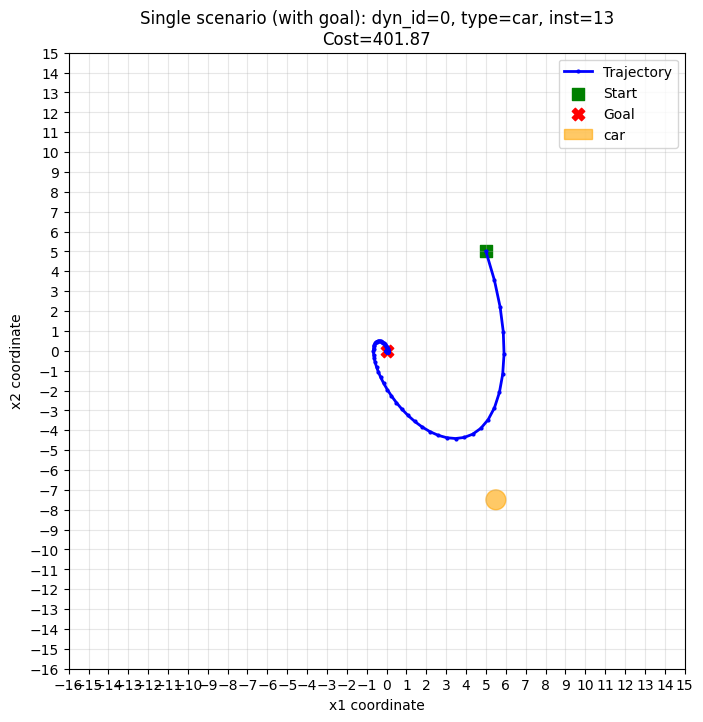

In [23]:
load_and_plot_trajectory(
    dyn_id=0,
    obs_type_name="car",
    instance_idx=13,
    db=db,
    grid_H=5,
    grid_W=5,
    base_cell_radius=0.5,
    traj_dir="traj_output_single"
)
